In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Data preparation

In [2]:
customer = pd.read_csv("customer_segmentation.csv")
customer.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
customer.tail(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,15-10-2012,40,84,...,7,0,0,0,0,0,0,3,11,1


In [4]:
customer.shape

(2240, 29)

In [5]:
customer.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [6]:
customer.dtypes

ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

In [7]:
customer['ID'].unique()

array([5524, 2174, 4141, ..., 7270, 8235, 9405], shape=(2240,))

each row represent different customer

In [8]:
# make a copy of dataset
customer_df = customer.copy()

## check missing value

In [9]:
customer_df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [10]:
mask_na = customer_df['Income'].isna()
customer_df[mask_na]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
10,1994,1983,Graduation,Married,NaN,1,0,15-11-2013,11,5,...,7,0,0,0,0,0,0,3,11,0
27,5255,1986,Graduation,Single,NaN,1,0,20-02-2013,19,5,...,1,0,0,0,0,0,0,3,11,0
43,7281,1959,PhD,Single,NaN,0,0,05-11-2013,80,81,...,2,0,0,0,0,0,0,3,11,0
48,7244,1951,Graduation,Single,NaN,2,1,01-01-2014,96,48,...,6,0,0,0,0,0,0,3,11,0
58,8557,1982,Graduation,Single,NaN,1,0,17-06-2013,57,11,...,6,0,0,0,0,0,0,3,11,0
71,10629,1973,2n Cycle,Married,NaN,1,0,14-09-2012,25,25,...,8,0,0,0,0,0,0,3,11,0
90,8996,1957,PhD,Married,NaN,2,1,19-11-2012,4,230,...,9,0,0,0,0,0,0,3,11,0
91,9235,1957,Graduation,Single,NaN,1,1,27-05-2014,45,7,...,7,0,0,0,0,0,0,3,11,0
92,5798,1973,Master,Together,NaN,0,0,23-11-2013,87,445,...,1,0,0,0,0,0,0,3,11,0
128,8268,1961,PhD,Married,NaN,0,1,11-07-2013,23,352,...,6,0,0,0,0,0,0,3,11,0


In [11]:
# there 24 record/observation with Nan Income. because its only 1% from total observations, we decided to remove from the data
# set
customer_df = customer_df.dropna()

In [12]:
customer_df.shape

(2216, 29)

## check outliers

<Axes: >

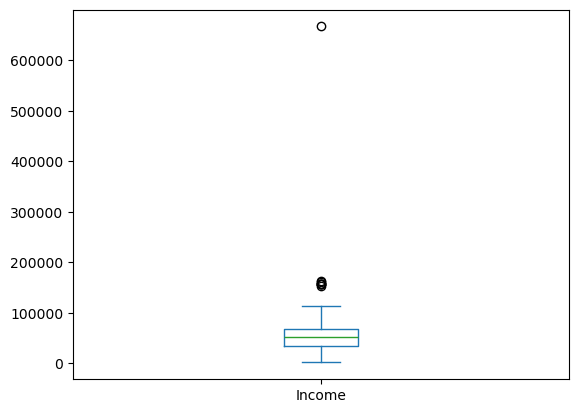

In [13]:
# income variable
customer_df['Income'].plot(kind = 'box')

In [14]:
customer_df.sort_values(by = 'Income', ascending = False)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2233,9432,1977,Graduation,Together,666666.0,1,0,02-06-2013,23,9,...,6,0,0,0,0,0,0,3,11,0
617,1503,1976,PhD,Together,162397.0,1,1,03-06-2013,31,85,...,1,0,0,0,0,0,0,3,11,0
687,1501,1982,PhD,Married,160803.0,0,0,04-08-2012,21,55,...,0,0,0,0,0,0,0,3,11,0
1300,5336,1971,Master,Together,157733.0,1,0,04-06-2013,37,39,...,1,0,0,0,0,0,0,3,11,0
164,8475,1973,PhD,Married,157243.0,0,1,01-03-2014,98,20,...,0,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1975,10311,1969,Graduation,Married,4428.0,0,1,05-10-2013,0,16,...,1,0,0,0,0,0,0,3,11,0
1846,9931,1963,PhD,Married,4023.0,1,1,23-06-2014,29,5,...,19,0,0,0,0,0,0,3,11,0
1524,11110,1973,Graduation,Single,3502.0,1,0,13-04-2013,56,2,...,14,0,0,0,0,0,0,3,11,0
21,5376,1979,Graduation,Married,2447.0,1,0,06-01-2013,42,1,...,1,0,0,0,0,0,0,3,11,0


In [15]:
# theres 1 outlier with extreme value of income 666666. we remove it from the data set
customer_df = customer_df[customer_df['Income'] != 666666]

In [16]:
# variable Kidhome
customer_df['Kidhome'].value_counts()

Kidhome
0    1283
1     886
2      46
Name: count, dtype: int64

In [17]:
# variable Teenhome
customer_df['Teenhome'].value_counts()

Teenhome
0    1146
1    1018
2      51
Name: count, dtype: int64

In [18]:
# Variable Recency
customer_df['Recency'].value_counts()

Recency
56    37
30    32
54    32
46    31
92    30
      ..
41    15
59    14
22    13
7     12
44    11
Name: count, Length: 100, dtype: int64

In [19]:
# Variable Year_Birth
customer_df['Year_Birth'].describe()

count    2215.000000
mean     1968.816704
std        11.987000
min      1893.000000
25%      1959.000000
50%      1970.000000
75%      1977.000000
max      1996.000000
Name: Year_Birth, dtype: float64

In [20]:
customer_df.sort_values(by = 'Year_Birth', ascending = True)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
239,11004,1893,2n Cycle,Single,60182.0,0,1,17-05-2014,23,8,...,4,0,0,0,0,0,0,3,11,0
339,1150,1899,PhD,Together,83532.0,0,0,26-09-2013,36,755,...,1,0,0,1,0,0,0,3,11,0
192,7829,1900,2n Cycle,Divorced,36640.0,1,0,26-09-2013,99,15,...,5,0,0,0,0,0,1,3,11,0
1950,6663,1940,PhD,Single,51141.0,0,0,08-07-2013,96,144,...,5,0,0,0,0,0,0,3,11,0
424,6932,1941,PhD,Married,93027.0,0,0,13-04-2013,77,1285,...,2,0,0,1,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
696,8315,1995,Graduation,Single,34824.0,0,0,26-03-2014,65,4,...,6,0,0,0,0,0,0,3,11,0
1850,4427,1995,2n Cycle,Single,83257.0,0,0,18-09-2012,56,536,...,6,1,0,1,0,0,1,3,11,1
2213,3661,1995,2n Cycle,Single,80617.0,0,0,12-10-2012,42,594,...,2,0,0,0,0,0,0,3,11,0
1170,193,1996,Basic,Married,14421.0,0,0,17-02-2014,81,0,...,5,1,0,0,0,0,0,3,11,0


In [21]:
# there are 3 observaition that hase BoD early than 1900 indicated  that their age is more than 120 years.
# which is mostly impossible. we remove from the datasets
customer_df = customer_df[customer_df['Year_Birth'] != 1900]
customer_df = customer_df[customer_df['Year_Birth'] != 1899]
customer_df = customer_df[customer_df['Year_Birth'] != 1893]
customer_df.sort_values(by = 'Year_Birth', ascending = True)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
1950,6663,1940,PhD,Single,51141.0,0,0,08-07-2013,96,144,...,5,0,0,0,0,0,0,3,11,0
424,6932,1941,PhD,Married,93027.0,0,0,13-04-2013,77,1285,...,2,0,0,1,0,0,0,3,11,0
1923,4994,1943,Master,Single,77598.0,0,0,01-10-2013,53,1193,...,3,0,0,1,0,0,0,3,11,0
1150,1453,1943,PhD,Widow,57513.0,0,0,06-07-2013,59,735,...,6,0,0,0,0,0,0,3,11,0
415,7106,1943,PhD,Married,75865.0,0,0,31-03-2014,73,483,...,1,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
747,10548,1995,Graduation,Single,71163.0,0,0,09-03-2014,30,283,...,1,0,0,0,0,0,0,3,11,0
1850,4427,1995,2n Cycle,Single,83257.0,0,0,18-09-2012,56,536,...,6,1,0,1,0,0,1,3,11,1
2213,3661,1995,2n Cycle,Single,80617.0,0,0,12-10-2012,42,594,...,2,0,0,0,0,0,0,3,11,0
46,9909,1996,2n Cycle,Married,7500.0,0,0,09-11-2012,24,3,...,9,0,0,0,0,0,0,3,11,1


## Checking typos

In [22]:
customer_df['Education'].value_counts()

Education
Graduation    1115
PhD            480
Master         365
2n Cycle       198
Basic           54
Name: count, dtype: int64

In [23]:
customer_df['Marital_Status'].value_counts()

Marital_Status
Married     857
Together    571
Single      470
Divorced    231
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [24]:
# recategorise the marital status of widow, alone, absurd, and YOLO
customer_df['Marital_Status'] = customer_df['Marital_Status'].replace('YOLO', 'Single')
customer_df['Marital_Status'] = customer_df['Marital_Status'].replace('Alone', 'Single')
customer_df['Marital_Status'] = customer_df['Marital_Status'].replace('Absurd', 'Single')
customer_df['Marital_Status'] = customer_df['Marital_Status'].replace('Widow', 'Divorced')

customer_df['Marital_Status'].value_counts()

Marital_Status
Married     857
Together    571
Single      477
Divorced    307
Name: count, dtype: int64

# DATA EXPLORATION

## Create new Variable

In [25]:
# Variable Monetary, representing total spending of customer
customer_df['Spending'] = customer_df['MntWines'] + customer_df['MntFruits'] + customer_df['MntMeatProducts'] + customer_df['MntFishProducts']+ customer_df['MntSweetProducts'] + customer_df['MntGoldProds']

In [26]:
# Variable Frequency, representing total number of purchases each customer
customer_df['Frequency'] = customer_df['NumWebPurchases'] + customer_df['NumStorePurchases']

In [27]:
customer_df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Spending,Frequency
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,0,0,0,3,11,1,1617,12
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,0,0,0,3,11,0,27,3
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,0,0,0,3,11,0,776,18
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,0,0,0,0,3,11,0,53,6
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,0,0,0,0,3,11,0,422,11


# check the distribution of some varibale

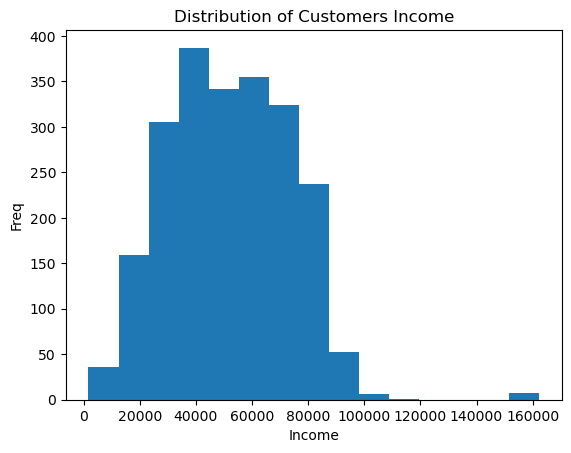

In [28]:
# plot the income variable using histogram
plt.hist(customer_df['Income'], bins = 15)
plt.xlabel('Income')
plt.ylabel('Freq')
plt.title('Distribution of Customers Income')
plt.show()

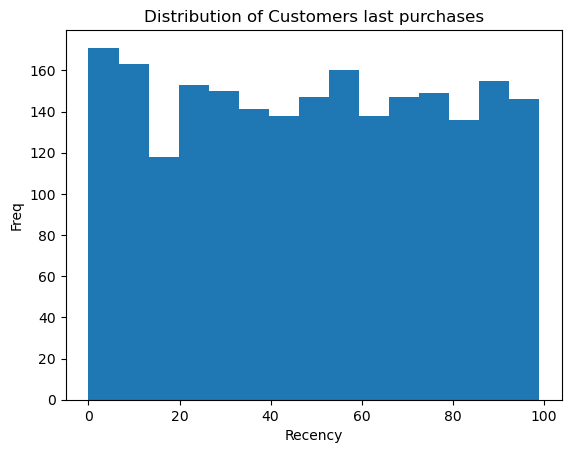

In [29]:
# plot the recency variable using histogram
plt.hist(customer_df['Recency'], bins = 15)
plt.xlabel('Recency')
plt.ylabel('Freq')
plt.title('Distribution of Customers last purchases')
plt.show()

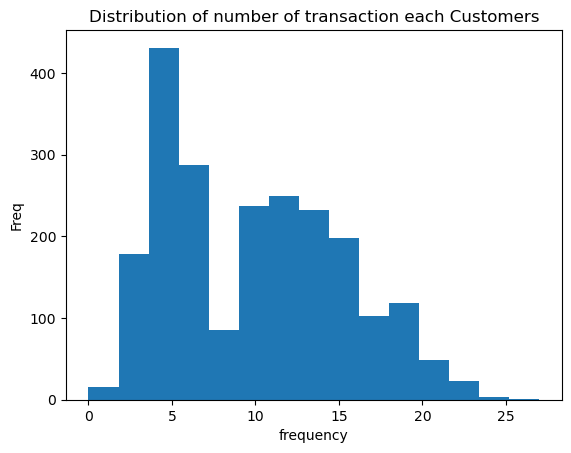

In [30]:
# plot the frequency variable using histogram
plt.hist(customer_df['Frequency'], bins = 15)
plt.xlabel('frequency')
plt.ylabel('Freq')
plt.title('Distribution of number of transaction each Customers')
plt.show()

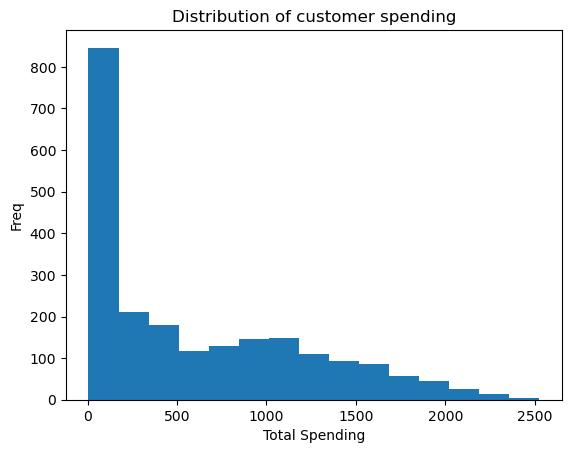

In [31]:
# plot the monetary variable using histogram
plt.hist(customer_df['Spending'], bins = 15)
plt.xlabel('Total Spending')
plt.ylabel('Freq')
plt.title('Distribution of customer spending')
plt.show()

# DATA MODELING

# K-Mean Cluster

### feature engineering

In [32]:
customer_df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Spending', 'Frequency'],
      dtype='object')

In [33]:
features = ['Income', 'Recency', 'Spending', 'Frequency']

In [34]:
# select some feature for clustering analysis
data = customer_df[features]
data

,Income,Recency,Spending,Frequency
0,58138.0,58,1617,12
1,46344.0,38,27,3
2,71613.0,26,776,18
3,26646.0,26,53,6
4,58293.0,94,422,11
...,...,...,...,...
2235,61223.0,46,1341,13
2236,64014.0,56,444,13
2237,56981.0,91,1241,15
2238,69245.0,8,843,16


In [35]:
# scale the feature
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_scale = scaler.fit_transform(data)

In [36]:
data_scale = pd.DataFrame(data_scale, columns=features)
data_scale

,Income,Recency,Spending,Frequency
0,0.287105,0.310353,1.676245,0.403150
1,-0.260882,-0.380813,-0.963297,-1.320259
2,0.913196,-0.795514,0.280110,1.552090
3,-1.176114,-0.795514,-0.920135,-0.745789
4,0.294307,1.554453,-0.307562,0.211660
...,...,...,...,...
2207,0.430444,-0.104347,1.218061,0.594640
2208,0.560123,0.241237,-0.271040,0.594640
2209,0.233347,1.450778,1.052052,0.977620
2210,0.803172,-1.417564,0.391336,1.169110


### find the best "k"

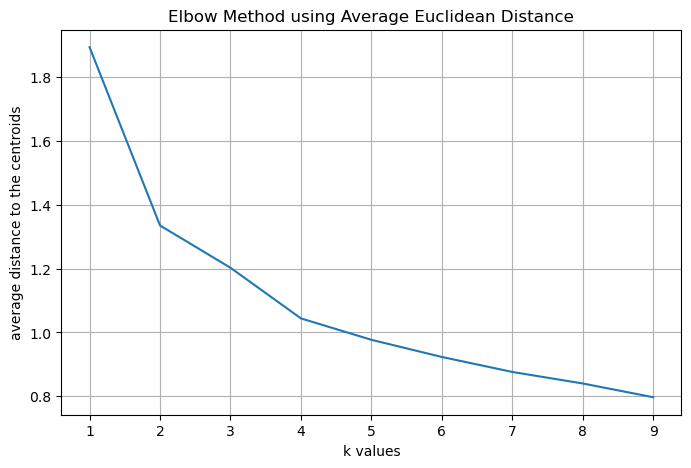

In [37]:
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
import math

#set the k values you would like to try
k_dist = range(1,10)
k_disValues = []

for k in k_dist:
    # 1. Fit KMeans on the entire scaled dataset
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit(data_scale)

    # 2. Calculate Euclidean distance from each point to its assigned centroid across ALL features
    # cdist computes pair-wise distance between points and centroids
    distances = np.min(cdist(data_scale, km.cluster_centers_, "euclidean"), axis=1)

    # 3. assign to np array
    k_disValues.append(np.mean(distances))

# Plotting the corrected elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_dist, k_disValues)
plt.xlabel("k values")
plt.ylabel("average distance to the centroids")
plt.title("Elbow Method using Average Euclidean Distance")
plt.grid(True)
plt.show()

### build k-mean model based on optimal k

In [38]:
model = KMeans(n_clusters = 4, random_state = 30)
model

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,30
,copy_x,True
,algorithm,'lloyd'


In [39]:
fit = model.fit_predict(data_scale)
fit

array([0, 1, 2, ..., 3, 2, 1], shape=(2212,), dtype=int32)

In [40]:
data['Cluster'] = fit
data

,Income,Recency,Spending,Frequency,Cluster
0,58138.0,58,1617,12,0
1,46344.0,38,27,3,1
2,71613.0,26,776,18,2
3,26646.0,26,53,6,1
4,58293.0,94,422,11,3
...,...,...,...,...,...
2235,61223.0,46,1341,13,0
2236,64014.0,56,444,13,3
2237,56981.0,91,1241,15,3
2238,69245.0,8,843,16,2


## Cluster Analysis

In [41]:
data['Cluster'].value_counts()

Cluster
1    977
2    466
3    405
0    364
Name: count, dtype: int64

In [42]:
kmean_summary = data.groupby(data['Cluster']).mean()
kmean_summary

,Income,Recency,Spending,Frequency
Cluster,,,,
0,79050.282967,64.752747,1535.420330,13.598901
1,33264.509724,46.872057,95.157625,5.168884
2,66094.371245,19.753219,947.287554,14.349785
3,56442.427160,73.733333,617.232099,12.839506


Cluster
0    79050.282967
1    33264.509724
2    66094.371245
3    56442.427160
Name: Income, dtype: float64


Text(0.5, 1.0, 'Average Income each cluster')

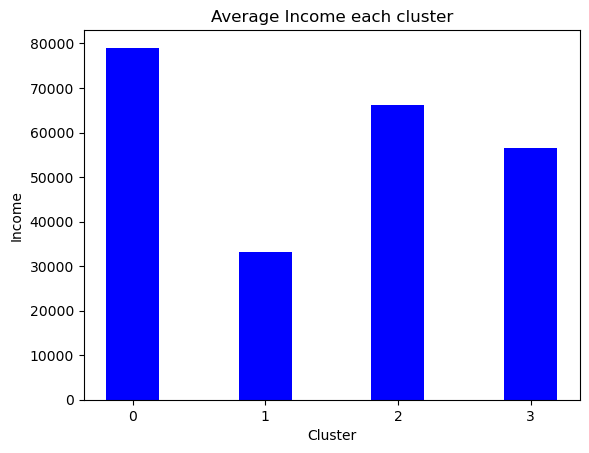

In [43]:
income = data['Income'].groupby(data['Cluster']).mean()
print(income)

plt.bar(list(range(4)), income, color='blue', width=0.4)
plt.xticks(list(range(4)), ["0","1","2","3"])
plt.xlabel("Cluster")
plt.ylabel("Income")
plt.title("Average Income each cluster")

Cluster
0    64.752747
1    46.872057
2    19.753219
3    73.733333
Name: Recency, dtype: float64


Text(0.5, 1.0, 'Recency each cluster')

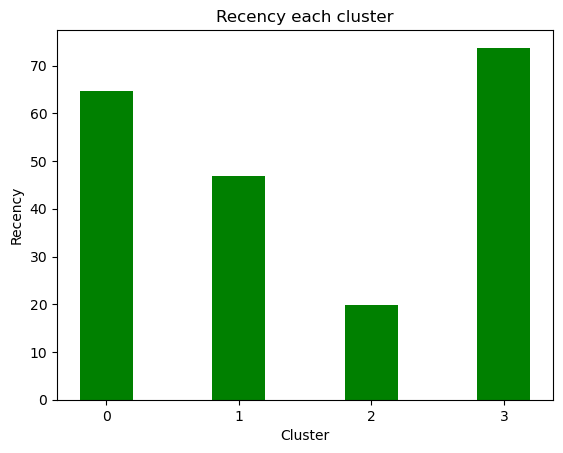

In [44]:
recency = data['Recency'].groupby(data['Cluster']).mean()
print(recency)

plt.bar(list(range(4)), recency, color='green', width=0.4)
plt.xticks(list(range(4)), ["0","1","2","3"])
plt.xlabel("Cluster")
plt.ylabel("Recency")
plt.title("Recency each cluster")

Cluster
0    1535.420330
1      95.157625
2     947.287554
3     617.232099
Name: Spending, dtype: float64


Text(0.5, 1.0, 'Average Spending each Cluster')

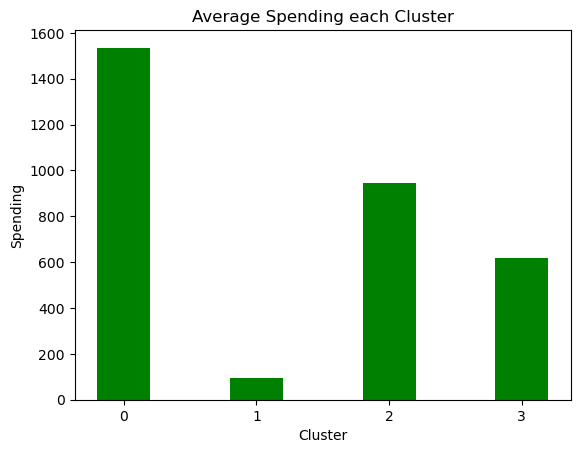

In [45]:
spending = data['Spending'].groupby(data['Cluster']).mean()
print(spending)

plt.bar(list(range(4)), spending, color='green', width=0.4)
plt.xticks(list(range(4)), ["0","1","2","3"])
plt.xlabel("Cluster")
plt.ylabel("Spending")
plt.title("Average Spending each Cluster")

Cluster
0    13.598901
1     5.168884
2    14.349785
3    12.839506
Name: Frequency, dtype: float64


Text(0.5, 1.0, 'Average number of transaction each Cluster')

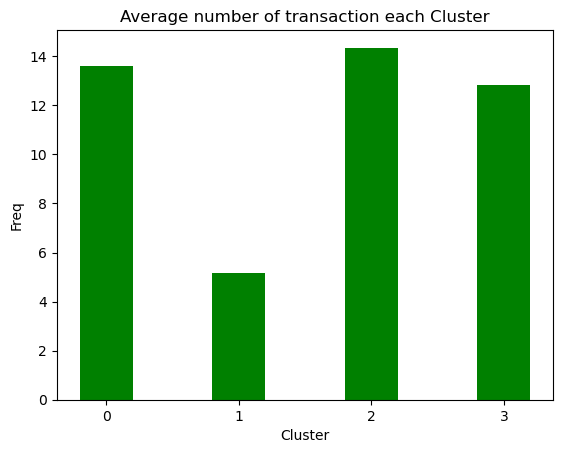

In [46]:
freq = data['Frequency'].groupby(data['Cluster']).mean()
print(freq)

plt.bar(list(range(4)), freq, color='green', width=0.4)
plt.xticks(list(range(4)), ["0","1","2","3"])
plt.xlabel("Cluster")
plt.ylabel("Freq")
plt.title("Average number of transaction each Cluster")

# Gaussian Mixture Model (GMM)

In [47]:
from sklearn.mixture import GaussianMixture

In [48]:
data_2 = customer_df[features]
data_scale_2 = scaler.fit_transform(data_2)
data_scale_2 = pd.DataFrame(data_scale_2, columns=features)
data_scale_2

,Income,Recency,Spending,Frequency
0,0.287105,0.310353,1.676245,0.403150
1,-0.260882,-0.380813,-0.963297,-1.320259
2,0.913196,-0.795514,0.280110,1.552090
3,-1.176114,-0.795514,-0.920135,-0.745789
4,0.294307,1.554453,-0.307562,0.211660
...,...,...,...,...
2207,0.430444,-0.104347,1.218061,0.594640
2208,0.560123,0.241237,-0.271040,0.594640
2209,0.233347,1.450778,1.052052,0.977620
2210,0.803172,-1.417564,0.391336,1.169110


In [49]:
gmm = GaussianMixture(
    n_components=4,
    covariance_type='full',
    random_state=30)

gmm.fit(data_scale_2)

,n_components,4
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,30


In [50]:
clusters_gmm = gmm.predict(data_scale_2)

data_2['Cluster_gmm'] = clusters_gmm
data_2

,Income,Recency,Spending,Frequency,Cluster_gmm
0,58138.0,58,1617,12,0
1,46344.0,38,27,3,1
2,71613.0,26,776,18,3
3,26646.0,26,53,6,1
4,58293.0,94,422,11,3
...,...,...,...,...,...
2235,61223.0,46,1341,13,0
2236,64014.0,56,444,13,3
2237,56981.0,91,1241,15,0
2238,69245.0,8,843,16,2


In [51]:
gmm_summary = data_2.groupby(data_2['Cluster_gmm']).mean()
gmm_summary

,Income,Recency,Spending,Frequency
Cluster_gmm,,,,
0,73178.144186,71.753488,1295.330233,13.311628
1,31141.149394,48.608345,52.323015,4.458950
2,72618.713115,22.368852,1304.106557,14.653005
3,50148.534918,49.441308,401.346211,11.124814


In [52]:
probabilities = np.round(gmm.predict_proba(data_scale_2),2)
probabilities = pd.DataFrame(probabilities, columns = ['cluster 0', 'cluster 1', 'cluster 2', 'cluster 3'])
probabilities

,cluster 0,cluster 1,cluster 2,cluster 3
0,0.92,0.00,0.08,0.00
1,0.00,0.97,0.00,0.03
2,0.01,0.00,0.35,0.64
3,0.00,0.96,0.00,0.04
4,0.01,0.00,0.00,0.99
...,...,...,...,...
2207,0.52,0.00,0.48,0.00
2208,0.04,0.00,0.00,0.96
2209,1.00,0.00,0.00,0.00
2210,0.00,0.00,0.97,0.02
